## Figure 6

Find peptides with no measured ratio change, output that list of no-change peptides.
(A) vignette one example of that happening where it's a SAAV or something; 
(B) "global" analysis of how often that happens or how big a deal it is

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns  # optional, remove if you want pure matplotlib

base_dir = Path.cwd()  # adjust if your notebook cwd is not SPRG/bin/06_homology
data_path = (
    base_dir
    / ".."
    / ".."
    / "data"
    / "02_stability_homogeneity"
    / "DIANN"
    / "SPRG_DIANN_analysis.pr_matrix.tsv"
)

data_path = data_path.resolve()

df = pd.read_csv(data_path, sep="\t")

df.head()


,Protein.Group,Protein.Ids,Protein.Names,Genes,First.Protein.Description,Proteotypic,Stripped.Sequence,Modified.Sequence,Precursor.Charge,Precursor.Id,...,E:\SPRG\42\Encyclopedia_search\raw\230109_neg20_06C.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_01A.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_01B.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_01C.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_06A.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_06B.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_06C.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_11A.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_11B.raw,E:\SPRG\42\Encyclopedia_search\raw\230109_RT_11C.raw
0,P36578,P36578,RL4_HUMAN,RPL4,60S ribosomal protein L4,1,AAAAAAALQAK,AAAAAAALQAK,1,AAAAAAALQAK1,...,NaN,5224.19,NaN,NaN,NaN,NaN,NaN,6135.35,NaN,NaN
1,P36578,P36578,RL4_HUMAN,RPL4,60S ribosomal protein L4,1,AAAAAAALQAK,AAAAAAALQAK,2,AAAAAAALQAK2,...,NaN,317657.00,NaN,NaN,286275.0,129794.00,NaN,300970.00,48314.9,NaN
2,Q1LZB0,Q1LZB0;F1MK36,DDRGK_BOVIN,DDRGK1,DDRGK domain-containing protein 1,1,AAAAAQEPLHNEEVPAAAGR,AAAAAQEPLHNEEVPAAAGR,3,AAAAAQEPLHNEEVPAAAGR3,...,23415.5,NaN,NaN,12240.2,NaN,9386.92,17009.0,NaN,NaN,13395.3
3,A4FUD0,A4FUD0,A4FUD0_BOVIN,MTHFD1,"C-1-tetrahydrofolate synthase, cytoplasmic",1,AAAAPSSFQLLYDLK,AAAAPSSFQLLYDLK,2,AAAAPSSFQLLYDLK2,...,2906160.0,448509.00,2009650.0,2651080.0,327363.0,2100930.00,2427340.0,369605.00,1897660.0,2576600.0
4,E1BGI0,E1BGI0,E1BGI0_BOVIN,ABCB11,Bile salt export pump,1,AAAASIFETIDR,AAAASIFETIDR,2,AAAASIFETIDR2,...,98389.1,13362.40,23471.9,114753.0,NaN,91250.60,122023.0,NaN,24228.4,129713.0


In [7]:
PEPTIDE_COL = "Stripped.Sequence"
PROTEIN_COL = "Protein.Names"
HOMO_COL    = "homology_class"

raw_cols = [c for c in df.columns if c.endswith(".raw")]

df_filenames = [c.split("\\")[-1] for c in raw_cols]

col_to_fname = {c: c.split("\\")[-1] for c in raw_cols}

import re

def extract_mixture_letter(fname):
    # regex: capture A/B/C before ".raw" at the end of string
    m = re.search(r"([ABC])\.raw$", fname)
    if m:
        return m.group(1)
    return None

fname_to_mix = {fname: extract_mixture_letter(fname) for fname in col_to_fname.values()}
fname_to_mix

{'42_exploris480_DIA_A.raw': 'A',
 '42_exploris480_DIA_B.raw': 'B',
 '42_exploris480_DIA_C.raw': 'C',
 '220602_ABRF_ratio_A.raw': 'A',
 '220602_ABRF_ratio_B.raw': 'B',
 '220602_ABRF_ratio_C.raw': 'C',
 '230109_neg20_06A.raw': 'A',
 '230109_neg20_06B.raw': 'B',
 '230109_neg20_06C.raw': 'C',
 '230109_RT_01A.raw': 'A',
 '230109_RT_01B.raw': 'B',
 '230109_RT_01C.raw': 'C',
 '230109_RT_06A.raw': 'A',
 '230109_RT_06B.raw': 'B',
 '230109_RT_06C.raw': 'C',
 '230109_RT_11A.raw': 'A',
 '230109_RT_11B.raw': 'B',
 '230109_RT_11C.raw': 'C'}

In [8]:
# set these based on the suffix_counts output
HUMAN_SUFFIXES  = ("_HUMAN",)
BOVINE_SUFFIXES = ("_BOVIN")
TROUT_PREFIXES  = ("XP_", "NP_")

def infer_species(row):
    species = set()
    
    # Names-based detection for HUMAN and BOVINE
    names = str(row["Protein.Names"]).split(";")
    for name in names:
        name = name.strip()
        if name.endswith(HUMAN_SUFFIXES):
            species.add("human")
        elif name.endswith(BOVINE_SUFFIXES):
            species.add("bovine")
    
    # Id-based detection for TROUT (RefSeq accessions)
    ids = str(row["Protein.Ids"]).split(";")
    for pid in ids:
        pid = pid.strip()
        if pid.startswith(TROUT_PREFIXES):
            species.add("trout")
    
    return species

df["species_set"] = df.apply(infer_species, axis=1)

def classify(s):
    if s == {"human"}: return "human_only"
    if s == {"bovine"}: return "bovine_only"
    if s == {"trout"}: return "trout_only"
    if s == {"human","bovine"}: return "human_bovine_shared"
    if s == {"human","trout"}:  return "human_trout_shared"
    if s == {"bovine","trout"}: return "bovine_trout_shared"
    if s == {"human","bovine","trout"}: return "all_three_shared"
    return "unknown"

df["homology_class"] = df["species_set"].apply(classify)
df["homology_class"].value_counts()

homology_class
human_only             10832
trout_only             10189
bovine_only             7318
human_bovine_shared     3748
all_three_shared        2328
human_trout_shared      1383
bovine_trout_shared      239
unknown                   16
Name: count, dtype: int64

In [17]:
ID_COL = "Protein.Ids"

long_abrf = df[[PEPTIDE_COL, HOMO_COL, ID_COL] + raw_cols].copy()

long_abrf = long_abrf.melt(
    id_vars=[PEPTIDE_COL, HOMO_COL, ID_COL],
    value_vars=raw_cols,
    var_name="raw_file",
    value_name="intensity"
)

# Map raw_file → filename → A/B/C
long_abrf["mixture"] = long_abrf["raw_file"].map(
    lambda col: fname_to_mix[col_to_fname[col]]
)

# Clean
long_abrf = long_abrf.replace([np.inf, -np.inf], np.nan)
long_abrf = long_abrf.dropna(subset=["intensity"])
long_abrf = long_abrf[long_abrf["intensity"] > 0]

wide_abrf = long_abrf.pivot_table(
    index=[PEPTIDE_COL, ID_COL, HOMO_COL],
    columns="mixture",
    values="intensity",
    aggfunc="median"   # median across all A, all B, all C
).reset_index()

wide_abrf.columns.name = None

for a, b in [("A","B"), ("B","C"), ("A","C")]:
    if a in wide_abrf.columns and b in wide_abrf.columns:
        wide_abrf[f"log2_{a}{b}"] = np.log2(wide_abrf[a] / wide_abrf[b])

wide_abrf = wide_abrf.replace([np.inf, -np.inf], np.nan)
wide_abrf = wide_abrf.dropna(subset=["log2_AB"])

wide_abrf.head()

,Stripped.Sequence,Protein.Ids,homology_class,A,B,C,log2_AB,log2_BC,log2_AC
0,AAAAAAALQAK,P36578,human_only,125790.00,58105.20,NaN,1.114278,NaN,NaN
2,AAAAPSSFQLLYDLK,A4FUD0,bovine_only,340110.00,1978805.00,2516230.00,-2.540556,-0.346634,-2.887190
3,AAAASIFETIDR,E1BGI0,bovine_only,13362.40,43915.65,106571.05,-1.716556,-1.279009,-2.995565
4,AAAASLHSDSFSATSVHMAGASMAK,XP_038870160.1,trout_only,81049.65,98208.35,111928.00,-0.277040,-0.188653,-0.465693
5,AAADGPMK,XP_038832514.1;XP_038850797.1,trout_only,201869.00,97230.45,191617.00,1.053939,-0.978745,0.075194


Index(['homology_class', 'count'], dtype='object')


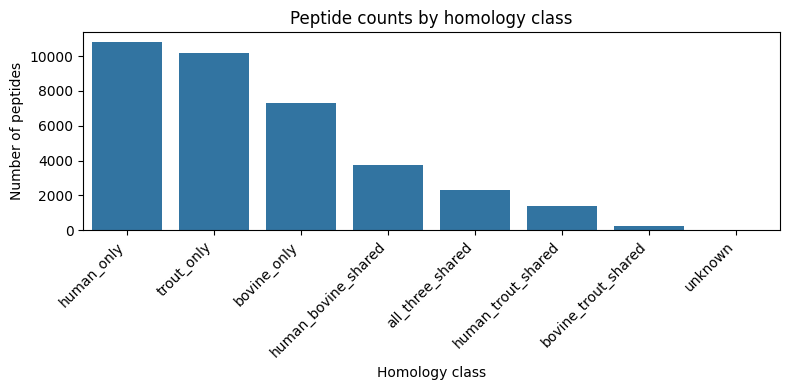

In [18]:
counts = (
    df["homology_class"]
    .value_counts()
    .to_frame(name="count")
    .reset_index()
    .rename(columns={"index": "homology_class"})
)

print(counts.columns)  # sanity check: should be Index(['homology_class', 'count'], dtype='object')

plt.figure(figsize=(8, 4))
sns.barplot(
    data=counts,
    x="homology_class",
    y="count",
    order=counts.sort_values("count", ascending=False)["homology_class"]
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Homology class")
plt.ylabel("Number of peptides")
plt.title("Peptide counts by homology class")
plt.tight_layout()
plt.show()


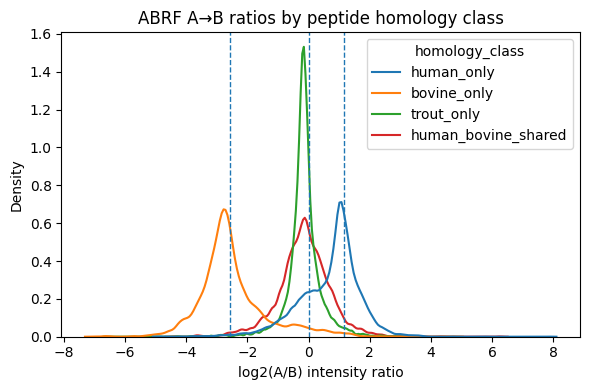

In [19]:
classes_to_plot = [
    "human_only",
    "bovine_only",
    "trout_only",
    "human_bovine_shared"
]

import numpy as np

expected_log2 = {
    "human":  np.log2(45 / 20),   # A vs B
    "bovine": np.log2(5  / 30),
    "trout":  np.log2(50 / 50),
}

plot_df = wide_abrf[wide_abrf["homology_class"].isin(classes_to_plot)].copy()

plt.figure(figsize=(6, 4))
sns.kdeplot(
    data=plot_df,
    x="log2_AB",
    hue="homology_class",
    common_norm=False,
    bw_adjust=0.5
)

for sp, val in expected_log2.items():
    plt.axvline(val, linestyle="--", linewidth=1)

plt.xlabel("log2(A/B) intensity ratio")
plt.title("ABRF A→B ratios by peptide homology class")
plt.tight_layout()
plt.show()


#### What human_only peptides are around the intensity ratio zero?

In [22]:
ZERO_WINDOW = 0.5

flat_human = wide_abrf[
    (wide_abrf["homology_class"] == "human_only") &
    (wide_abrf["log2_AB"].abs() < ZERO_WINDOW)
].copy()

flat_human = flat_human.sort_values("log2_AB")
flat_human.iloc[:20]

,Stripped.Sequence,Protein.Ids,homology_class,A,B,C,log2_AB,log2_BC,log2_AC
20038,NVQVYNPTPNSLDVR,Q99715;F1N401,human_only,73527.90,103917.7,162008.00,-0.499078,-0.640624,-1.139701
25627,TVIGDHGDELFSVFGAPFLK,P23141;A0A3Q1MQJ1,human_only,315184.50,445145.0,84521.80,-0.498079,2.396880,1.898801
3839,DGLGGLPDIVR,P45974;F1N3P2,human_only,95996.50,135487.0,97446.65,-0.497101,0.475470,-0.021631
21778,RTEEGPTLSYGR,P43243;F1MXI4,human_only,19031.30,26855.4,6221.97,-0.496838,2.109769,1.612931
3865,DGPGFYTTR,P40939;A0A3Q1NDR1,human_only,675749.50,953038.0,965227.00,-0.496045,-0.018335,-0.514380
1352,AITIASAVNCPLYIVHVMSK,Q14117,human_only,333737.00,470579.5,494769.50,-0.495727,-0.072318,-0.568045
27865,VQELQQQSAR,Q7Z406;F1MM57,human_only,30171.10,42533.4,68326.10,-0.495429,-0.683841,-1.179269
15603,LFVEDSIHDEFVRR,O75891,human_only,211994.10,298759.0,42782.90,-0.494958,2.803876,2.308918
14813,LAEDEAFQR,Q15149;A0A3Q1MRS3,human_only,114601.00,161382.0,141601.50,-0.493860,0.188643,-0.305217
15211,LDIDPETITWQR,P11586;A4FUD0,human_only,2513260.00,3538680.0,4158600.00,-0.493651,-0.232887,-0.726538


In [24]:
flat_human_peps = flat_human["Stripped.Sequence"].unique()
all_peptides = wide_abrf["Stripped.Sequence"].unique()

from collections import defaultdict

def bucket_by_length(peps):
    d = defaultdict(list)
    for s in peps:
        d[len(s)].append(s)
    return d

all_by_len = bucket_by_length(all_peptides)

def is_hamming1(a, b):
    if len(a) != len(b):
        return False
    diff = 0
    for x, y in zip(a, b):
        if x != y:
            diff += 1
            if diff > 1:
                return False
    return diff == 1

records = []

for hpep in flat_human_peps:
    L = len(hpep)
    candidates = all_by_len.get(L, [])
    
    for other in candidates:
        if other == hpep:
            continue
        if is_hamming1(hpep, other):
            # pull annotation + ABRF ratio from wide_abrf
            row = wide_abrf.loc[wide_abrf["Stripped.Sequence"] == other]
            if row.empty:
                continue
            row = row.iloc[0]
            
            records.append({
                "human_flat_peptide": hpep,
                "neighbor_peptide": other,
                "neighbor_homology": row["homology_class"],
                "neighbor_log2_AB": row["log2_AB"],
                "neighbor_is_flat": abs(row["log2_AB"]) < ZERO_WINDOW
            })

neighbors_df = pd.DataFrame(records)
neighbors_df.head(), neighbors_df.shape

neighbors_df.to_csv(
    "../../data/06_homology/flat_ratio_peptides_with_saav.csv",
    index=False
)


In [ ]:
id_lookup = wide_abrf[["Stripped.Sequence", "Protein.Ids"]].drop_duplicates()
id_lookup = id_lookup.set_index("Stripped.Sequence")["Protein.Ids"]

neighbors_df["human_protein_ids"] = neighbors_df["human_flat_peptide"].map(id_lookup)
neighbors_df["neighbor_protein_ids"] = neighbors_df["neighbor_peptide"].map(id_lookup)
neighbors_df.head()

neighbors_df.to_csv("../../data/06_homology/flat_ratio_peptides_with_saav_with_ids.csv", index=False)
